# Reward Types and Reward Criteria in Reinforcement Learning

The **reward function** defines the immediate feedback received after a transition, while a **reward criterion** defines how rewards are accumulated over time.

$$
\boxed{
\text{Reward function: }
(S_t,A_t,S_{t+1}) \rightarrow R_{t+1}
}
$$

$$
\boxed{
\text{Reward criterion: }
R_1,R_2,\ldots \rightarrow \text{one objective to maximize}
}
$$

This notebook uses one GridWorld to explain:

- reward types,
- advantages and disadvantages,
- situations where each type is useful,
- total, discounted, and average reward criteria,
- practical reward-design checks,
- executable examples and graphs.

## 1. Imports and Reproducibility

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)

# Part I — Common GridWorld

To compare reward designs fairly, the environment dynamics remain fixed while only the reward function changes.

The environment contains:

- a $7\times7$ grid,
- start state $S=(0,0)$,
- goal state $G=(6,6)$,
- blocked cells,
- four actions: `Up`, `Down`, `Left`, and `Right`.

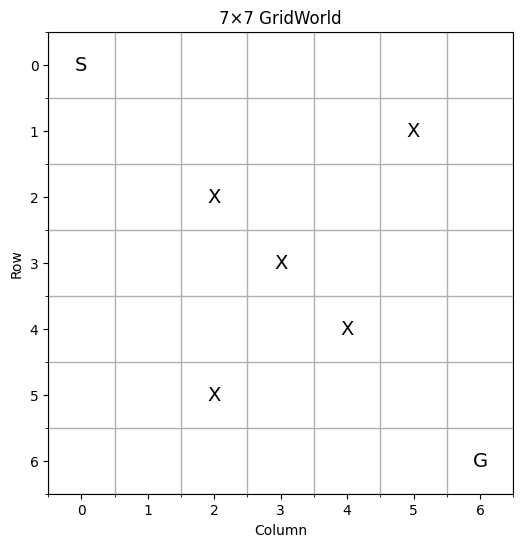

In [2]:
class Gridworld:
    def __init__(self, size=7):
        self.size = size
        self.start_state = (0, 0)
        self.goal_state = (6, 6)
        self.obstacles = {(2, 2), (3, 3), (4, 4), (5, 2), (1, 5)}
        self.actions = ("Up", "Down", "Left", "Right")

    def move(self, state, action):
        if state == self.goal_state:
            return state, True, {"collision": False}

        r, c = state

        if action == "Up":
            candidate = (max(r - 1, 0), c)
        elif action == "Down":
            candidate = (min(r + 1, self.size - 1), c)
        elif action == "Left":
            candidate = (r, max(c - 1, 0))
        elif action == "Right":
            candidate = (r, min(c + 1, self.size - 1))
        else:
            raise ValueError("Invalid action.")

        collision = candidate in self.obstacles
        if collision:
            candidate = state

        done = candidate == self.goal_state
        return candidate, done, {"collision": collision}

    def plot(self):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xlim(-0.5, self.size - 0.5)
        ax.set_ylim(self.size - 0.5, -0.5)
        ax.set_xticks(range(self.size))
        ax.set_yticks(range(self.size))
        ax.set_xticks(np.arange(-0.5, self.size, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, self.size, 1), minor=True)
        ax.grid(which="minor", linewidth=1)

        for r in range(self.size):
            for c in range(self.size):
                state = (r, c)
                if state in self.obstacles:
                    label = "X"
                elif state == self.start_state:
                    label = "S"
                elif state == self.goal_state:
                    label = "G"
                else:
                    label = ""

                if label:
                    ax.text(c, r, label, ha="center", va="center", fontsize=14)

        ax.set_xlabel("Column")
        ax.set_ylabel("Row")
        ax.set_title("7×7 GridWorld")
        plt.show()

env = Gridworld()
env.plot()

## 2. Episode Helpers

We compare two successful routes:

- **short route:** reaches the goal directly,
- **long route:** adds unnecessary left-right movements.

A useful reward should prefer the short route when faster completion is part of the real objective.

In [3]:
short_actions = ["Down"] * 6 + ["Right"] * 6
long_actions = ["Down"] * 6 + ["Right", "Left"] * 3 + ["Right"] * 6

def manhattan_distance(state, goal):
    return abs(state[0] - goal[0]) + abs(state[1] - goal[1])

def run_episode(env, actions, reward_fn, start_state=None):
    state = env.start_state if start_state is None else start_state
    trajectory = []

    for t, action in enumerate(actions):
        next_state, done, info = env.move(state, action)
        reward = reward_fn(state, action, next_state, done, info)

        trajectory.append({
            "t": t,
            "state": state,
            "action": action,
            "reward": reward,
            "next_state": next_state,
            "done": done,
        })

        state = next_state

        if done:
            break

    return trajectory

def get_rewards(trajectory):
    return [row["reward"] for row in trajectory]

def total_return(rewards):
    return float(np.sum(rewards))

# Part II — Reward Types

Reward types can overlap. For example, a reward can be both **dense** and **composite**.

The categories below describe common ways to construct the immediate reward signal.

# 3. Sparse / Terminal Reward

A sparse reward provides useful feedback only occasionally.

A terminal reward can be

$$
R_{t+1}
=
\begin{cases}
+1, & \text{goal reached},\\
0, & \text{otherwise}.
\end{cases}
$$

The reward tells the agent whether the task succeeded, but it gives little guidance during the episode.

In [4]:
def sparse_reward(state, action, next_state, done, info):
    return 1.0 if done else 0.0

short_sparse = run_episode(env, short_actions, sparse_reward)
long_sparse = run_episode(env, long_actions, sparse_reward)

print("Short route: steps =", len(short_sparse),
      ", return =", total_return(get_rewards(short_sparse)))
print("Long route : steps =", len(long_sparse),
      ", return =", total_return(get_rewards(long_sparse)))

Short route: steps = 12 , return = 1.0
Long route : steps = 18 , return = 1.0


### Advantages

- simple,
- closely tied to the actual success condition,
- does not force the agent to follow a hand-designed intermediate path.

### Disadvantages

- weak learning signal,
- exploration can be slow,
- difficult credit assignment in long episodes,
- the goal may be discovered rarely.

### When to use it

Use sparse rewards when:

- episodes are short,
- success is easy to discover,
- the state space is manageable,
- you want to avoid unnecessary shaping assumptions.

# 4. Dense / Progress Reward

A dense reward provides feedback on many or all transitions.

One progress reward is

$$
R_{t+1}
=
d(S_t,G)-d(S_{t+1},G),
$$

where $d$ is distance to the goal.

Therefore:

- moving closer gives positive reward,
- moving farther gives negative reward,
- no progress gives zero.

In [5]:
def progress_reward(state, action, next_state, done, info):
    old_d = manhattan_distance(state, env.goal_state)
    new_d = manhattan_distance(next_state, env.goal_state)
    return float(old_d - new_d)

short_progress = run_episode(env, short_actions, progress_reward)
long_progress = run_episode(env, long_actions, progress_reward)

print("Short progress return:", total_return(get_rewards(short_progress)))
print("Long progress return :", total_return(get_rewards(long_progress)))

Short progress return: 12.0
Long progress return : 12.0


The long route contains unnecessary movement, but the positive and negative progress rewards can cancel.

So a dense progress signal can give excellent **directional feedback** without necessarily penalizing delay.

### Advantages

- frequent feedback,
- faster exploration,
- easier credit assignment,
- useful when meaningful progress can be measured.

### Disadvantages

- requires a good progress measure,
- may reward shortcuts that are not truly desirable,
- can fail to penalize loops,
- can be harder to design correctly.

### When to use it

Use dense rewards when sparse success is difficult to discover and intermediate progress is measurable.

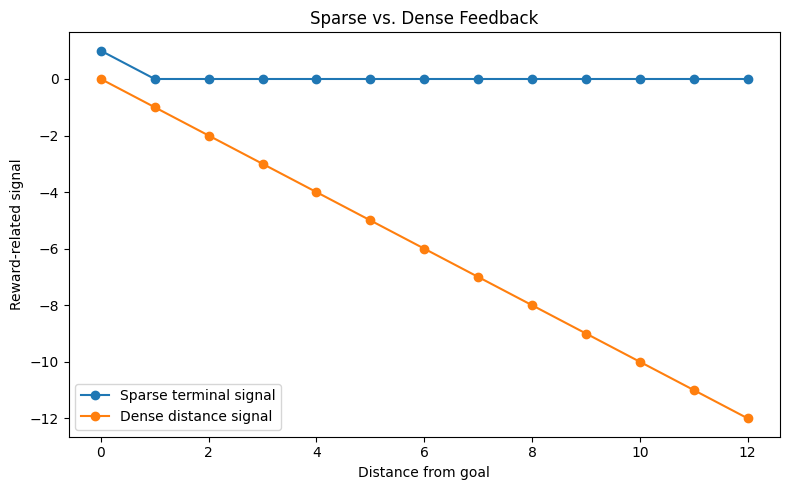

In [6]:
distances = np.arange(0, 13)
sparse_signal = np.where(distances == 0, 1.0, 0.0)
dense_signal = -distances.astype(float)

plt.figure(figsize=(8, 5))
plt.plot(distances, sparse_signal, marker="o", label="Sparse terminal signal")
plt.plot(distances, dense_signal, marker="o", label="Dense distance signal")
plt.xlabel("Distance from goal")
plt.ylabel("Reward-related signal")
plt.title("Sparse vs. Dense Feedback")
plt.legend()
plt.tight_layout()
plt.show()

# 5. Step Penalty / Time-Cost Reward

If finishing quickly matters, ordinary steps can receive a negative reward:

$$
R_{t+1}
=
\begin{cases}
0, & \text{goal reached},\\
-1, & \text{otherwise}.
\end{cases}
$$

Every unnecessary step lowers return.

In [7]:
def step_penalty_reward(state, action, next_state, done, info):
    return 0.0 if done else -1.0

short_step = run_episode(env, short_actions, step_penalty_reward)
long_step = run_episode(env, long_actions, step_penalty_reward)

print("Short route total:", total_return(get_rewards(short_step)))
print("Long route total :", total_return(get_rewards(long_step)))

Short route total: -11.0
Long route total : -17.0


### Advantages

- simple,
- encourages shorter trajectories,
- discourages unnecessary waiting and loops,
- useful when time or operating cost matters.

### Disadvantages

- gives little directional guidance,
- can make early exploration look uniformly bad,
- inappropriate when extra time is not actually undesirable.

### When to use it

Use a step penalty for:

- shortest-path problems,
- time minimization,
- resource consumption,
- tasks where every additional step has a real cost.

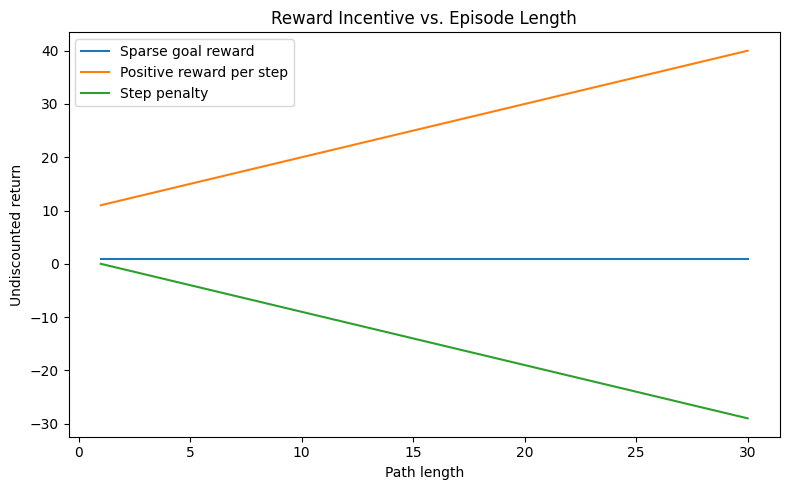

In [8]:
path_lengths = np.arange(1, 31)

sparse_returns = np.ones_like(path_lengths, dtype=float)
positive_step_returns = path_lengths + 10
step_penalty_returns = -(path_lengths - 1)

plt.figure(figsize=(8, 5))
plt.plot(path_lengths, sparse_returns, label="Sparse goal reward")
plt.plot(path_lengths, positive_step_returns, label="Positive reward per step")
plt.plot(path_lengths, step_penalty_returns, label="Step penalty")
plt.xlabel("Path length")
plt.ylabel("Undiscounted return")
plt.title("Reward Incentive vs. Episode Length")
plt.legend()
plt.tight_layout()
plt.show()

The graph shows why reward sign matters:

- sparse goal reward may not distinguish successful path length,
- positive per-step reward can make long episodes attractive,
- a step penalty makes unnecessary delay costly.

# 6. Shaped Reward

Reward shaping adds intermediate guidance to the original task reward.

A principled form is **potential-based shaping**:

$$
\boxed{
R'(s,a,s')
=
R(s,a,s')
+
\gamma\Phi(s')
-
\Phi(s)
}
$$

where $\Phi(s)$ is a potential function.

For this GridWorld:

$$
\Phi(s)=-d(s,G).
$$

States closer to the goal have higher potential.

In [9]:
GAMMA_SHAPING = 0.9

def potential(state):
    return -float(manhattan_distance(state, env.goal_state))

def base_reward(state, action, next_state, done, info):
    if info["collision"]:
        return -2.0
    if done:
        return 10.0
    return -1.0

def shaped_reward(state, action, next_state, done, info):
    base = base_reward(state, action, next_state, done, info)
    shaping = GAMMA_SHAPING * potential(next_state) - potential(state)
    return base + shaping

short_shaped = run_episode(env, short_actions, shaped_reward)
long_shaped = run_episode(env, long_actions, shaped_reward)

print("Short shaped total:", total_return(get_rewards(short_shaped)))
print("Long shaped total :", total_return(get_rewards(long_shaped)))

Short shaped total: 17.6
Long shaped total : 14.899999999999999


### Advantages

- more informative feedback,
- can accelerate learning,
- can inject useful domain knowledge,
- potential-based shaping has a principled structure.

### Disadvantages

- requires a meaningful potential function,
- poor shaping can distract the agent,
- reward scales can become unbalanced,
- design can become complicated.

### When to use it

Use shaping when the real reward is too sparse but useful domain knowledge can describe progress.

# 7. Composite Reward

Complex systems often have multiple objectives.

A composite reward can be written as

$$
\boxed{
R
=
w_gR_{\text{goal}}
+
w_pR_{\text{progress}}
+
w_sR_{\text{step}}
+
w_cR_{\text{collision}}.
}
$$

For example, the agent can be rewarded for reaching the goal and making progress while being penalized for delay and collisions.

In [10]:
def composite_reward(state, action, next_state, done, info):
    goal = 10.0 if done else 0.0

    old_d = manhattan_distance(state, env.goal_state)
    new_d = manhattan_distance(next_state, env.goal_state)
    progress = old_d - new_d

    step_cost = -0.1
    collision_cost = -2.0 if info["collision"] else 0.0

    return goal + 0.5 * progress + step_cost + collision_cost

short_composite = run_episode(env, short_actions, composite_reward)
long_composite = run_episode(env, long_actions, composite_reward)

print("Short composite total:", total_return(get_rewards(short_composite)))
print("Long composite total :", total_return(get_rewards(long_composite)))

Short composite total: 14.8
Long composite total : 14.200000000000001


### Advantages

- represents several objectives,
- flexible,
- useful in realistic control problems.

### Disadvantages

- weights can be difficult to tune,
- one term may dominate,
- objectives may conflict,
- the agent may exploit a loophole in one component.

### When to use it

Use composite rewards when several measurable objectives genuinely matter, such as:

- safety + speed,
- throughput + congestion,
- accuracy + energy use,
- task success + resource consumption.

# 8. Extrinsic and Intrinsic Reward

### Extrinsic reward

Comes from the real task objective.

Examples:

- reaching the goal,
- completing an order,
- avoiding a collision.

### Intrinsic reward

Adds motivation for exploration, novelty, or information gathering.

A simple conceptual form is

$$
R_t
=
R_t^{\text{extrinsic}}
+
\beta R_t^{\text{intrinsic}}.
$$

### Advantages of intrinsic reward

- helps exploration,
- useful when external reward is extremely sparse.

### Disadvantages

- novelty may become more attractive than the real task,
- additional tuning is needed.

### When to use it

Use intrinsic reward when **exploration itself** is the major difficulty.

# 9. Reward-Type Comparison

| Reward type | Main idea | Main advantage | Main disadvantage | Good situation |
|---|---|---|---|---|
| Sparse / terminal | Reward mainly at success | Simple and objective-aligned | Slow exploration | Small or easy episodic tasks |
| Dense / progress | Feedback throughout trajectory | Faster learning | Can encode wrong shortcuts | Measurable progress exists |
| Step penalty | Cost per step | Encourages efficiency | Weak directional guidance | Time/path minimization |
| Shaped | Add intermediate guidance | Better credit assignment | Harder to design | Sparse difficult tasks |
| Composite | Combine objectives | Flexible | Weight tuning and loopholes | Multi-objective systems |
| Intrinsic + extrinsic | Add exploration motivation | Helps discovery | May distract from task | Very sparse external reward |

# Part III — Reward Criteria

The reward function gives one immediate signal.

The **reward criterion** determines how the whole reward sequence is evaluated.

# 10. Total Episodic Reward

For a finite episode,

$$
\boxed{
G_{\text{total}}
=
\sum_{t=1}^{T}R_t.
}
$$

Every reward has equal weight.

In [11]:
def total_reward(rewards):
    return float(np.sum(rewards))

short_rewards = get_rewards(short_step)
long_rewards = get_rewards(long_step)

print("Short route total reward:", total_reward(short_rewards))
print("Long route total reward :", total_reward(long_rewards))

Short route total reward: -11.0
Long route total reward : -17.0


### Advantages

- simple,
- easy to interpret,
- no discount factor.

### Disadvantages

- unsuitable for unbounded continuing sums,
- does not automatically prefer earlier rewards,
- episode length can dominate the value.

### When to use it

Use total reward when the task is finite, episodic, and has a clear terminal condition.

# 11. Discounted Return

The discounted return is

$$
\boxed{
G_t
=
\sum_{k=0}^{\infty}
\gamma^kR_{t+k+1}.
}
$$

A future reward received $k$ steps later is weighted by

$$
\gamma^k.
$$

In [12]:
def discounted_return(rewards, gamma):
    return float(sum((gamma ** t) * reward for t, reward in enumerate(rewards)))

for gamma in [0.0, 0.5, 0.9, 0.99]:
    print(
        f"gamma={gamma:>4}: "
        f"{discounted_return(short_rewards, gamma):.6f}"
    )

gamma= 0.0: -1.000000
gamma= 0.5: -1.999023
gamma= 0.9: -6.861894
gamma=0.99: -10.466175


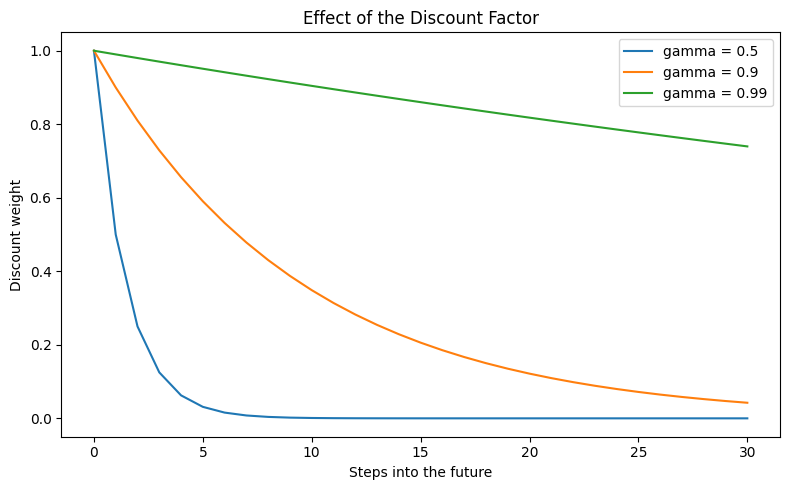

In [13]:
steps = np.arange(0, 31)

plt.figure(figsize=(8, 5))

for gamma in [0.5, 0.9, 0.99]:
    plt.plot(steps, gamma ** steps, label=f"gamma = {gamma}")

plt.xlabel("Steps into the future")
plt.ylabel("Discount weight")
plt.title("Effect of the Discount Factor")
plt.legend()
plt.tight_layout()
plt.show()

## 11.1 Earlier vs. Later Success

Using the sparse terminal reward, both successful routes have total reward

$$
1.
$$

Discounting can still prefer the route that reaches the goal earlier.

In [14]:
short_sparse_rewards = get_rewards(short_sparse)
long_sparse_rewards = get_rewards(long_sparse)

gamma = 0.9

criterion_demo = pd.DataFrame({
    "Route": ["Short", "Long"],
    "Steps": [len(short_sparse_rewards), len(long_sparse_rewards)],
    "Total reward": [
        total_reward(short_sparse_rewards),
        total_reward(long_sparse_rewards),
    ],
    "Discounted return": [
        discounted_return(short_sparse_rewards, gamma),
        discounted_return(long_sparse_rewards, gamma),
    ],
})

criterion_demo

,Route,Steps,Total reward,Discounted return
0,Short,12,1.0,0.313811
1,Long,18,1.0,0.166772


### Advantages

- handles long or infinite horizons,
- naturally values earlier reward more,
- controls the effective planning horizon.

### Disadvantages

- requires choosing $\gamma$,
- too-small $\gamma$ can make the agent shortsighted,
- the best $\gamma$ may not be obvious.

### When to use it

Use discounted return when future consequences matter but earlier outcomes should receive more weight.

# 12. Long-Run Average Reward

For a continuing task,

$$
\boxed{
\rho
=
\lim_{n\to\infty}
\frac{1}{n}
\mathbb E
\left[
\sum_{t=1}^{n}R_t
\right].
}
$$

This measures reward per time step in steady operation.

It is **not the same** as simply calculating the arithmetic mean of rewards from one finite episode.

In [15]:
def continuing_rewards(env, action_cycle, reward_fn, n_steps):
    state = env.start_state
    action_index = 0
    rewards = []

    for _ in range(n_steps):
        action = action_cycle[action_index]
        next_state, done, info = env.move(state, action)
        reward = reward_fn(state, action, next_state, done, info)
        rewards.append(reward)

        if done:
            state = env.start_state
            action_index = 0
        else:
            state = next_state
            action_index = (action_index + 1) % len(action_cycle)

    return np.asarray(rewards, dtype=float)

continuing = continuing_rewards(
    env,
    short_actions,
    step_penalty_reward,
    5000,
)

running_average = np.cumsum(continuing) / np.arange(1, len(continuing) + 1)

for n in [100, 1000, 5000]:
    print(
        f"After {n:>4} steps: "
        f"average reward = {running_average[n-1]:.6f}"
    )

After  100 steps: average reward = -0.920000
After 1000 steps: average reward = -0.917000
After 5000 steps: average reward = -0.916800


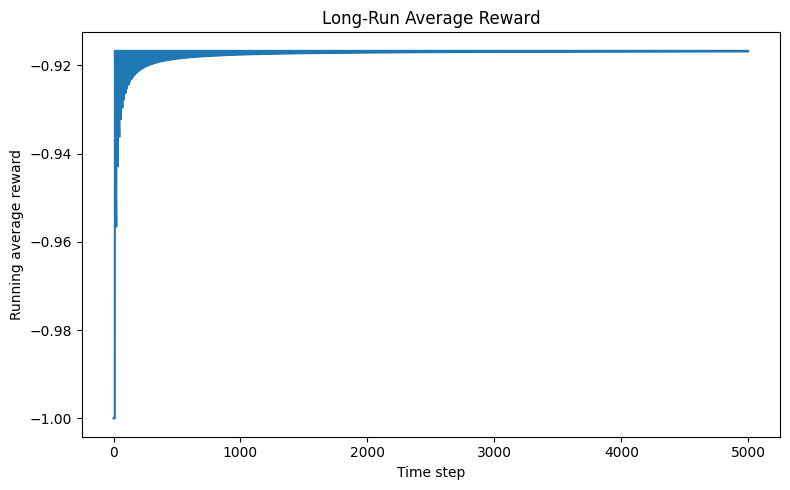

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(running_average)
plt.xlabel("Time step")
plt.ylabel("Running average reward")
plt.title("Long-Run Average Reward")
plt.tight_layout()
plt.show()

### Advantages

- natural for continuing tasks,
- directly measures steady-state performance,
- no discount factor is required.

### Disadvantages

- less natural for one-time episodes,
- transient behavior may receive less emphasis,
- analysis can be more specialized.

### When to use it

Use average reward for continuing systems such as:

- manufacturing operations,
- communication networks,
- inventory systems,
- service systems,
- other non-terminating control problems.

# 13. Reward-Criterion Comparison

| Criterion | Formula | Best situation | Main advantage | Main limitation |
|---|---|---|---|---|
| Total reward | $\sum_{t=1}^{T}R_t$ | Finite episodes | Simple | Not suitable for unbounded continuing sums |
| Discounted return | $\sum_{k=0}^{\infty}\gamma^kR_{t+k+1}$ | Long-horizon episodic or continuing tasks | Handles timing and future rewards | Requires $\gamma$ |
| Average reward | $\lim_{n\to\infty}\frac1n\mathbb E[\sum_{t=1}^{n}R_t]$ | Continuing tasks | Steady-state performance | Less natural for finite episodes |

# Part IV — Reward-Design Criteria

After selecting a reward type and return criterion, the reward itself should be checked carefully.

# 14. Criterion 1 — Alignment with the True Objective

Ask:

> If the agent perfectly maximizes this reward, will the resulting behavior actually satisfy the real objective?

The reward should not merely look reasonable. Its optimum should correspond to the behavior you want.

# 15. Criterion 2 — Informative Enough to Learn

If useful feedback is almost never observed, learning may be extremely slow.

Possible solutions include:

- progress rewards,
- reward shaping,
- curriculum design,
- intrinsic exploration bonuses.

But extra feedback should not introduce a new objective accidentally.

# 16. Criterion 3 — Correct Incentive for Time

If faster completion matters, unnecessary delay should reduce return.

A common design is

$$
R_{\text{step}}<0.
$$

Positive reward for every ordinary step can accidentally encourage long episodes.

# 17. Criterion 4 — Appropriate Scale

For a composite reward,

$$
R
=
w_1R_1+w_2R_2+\cdots,
$$

one component should not dominate simply because its numerical scale is much larger.

Check:

- magnitude,
- outliers,
- normalization,
- relative importance of each term.

# 18. Criterion 5 — No Easy Loopholes

The agent maximizes the mathematical reward, not the designer's intention.

Check whether it can gain reward by:

- cycling,
- delaying termination,
- repeatedly triggering a bonus,
- exploiting simulator artifacts,
- avoiding necessary but temporarily costly actions.

Always inspect the learned behavior.

# 19. Criterion 6 — Safety and Constraints

Reward penalties can discourage unsafe behavior such as:

- collisions,
- congestion,
- excessive force,
- energy violations.

For hard safety requirements, reward penalties alone may not be enough. Explicit constraints or action masking may also be required.

# 20. Code-Based Reward Sanity Check

Before a long training run, compare returns for behaviors that you already know are better or worse.

A simple test is

$$
\boxed{
\text{desired behavior should receive higher return than obviously worse behavior}.
}
$$

In [17]:
reward_functions = {
    "Sparse terminal": sparse_reward,
    "Progress": progress_reward,
    "Step penalty": step_penalty_reward,
    "Potential shaped": shaped_reward,
    "Composite": composite_reward,
}

rows = []

for name, reward_fn in reward_functions.items():
    short_traj = run_episode(env, short_actions, reward_fn)
    long_traj = run_episode(env, long_actions, reward_fn)

    short_value = total_return(get_rewards(short_traj))
    long_value = total_return(get_rewards(long_traj))

    rows.append({
        "Reward type": name,
        "Short-route return": short_value,
        "Long-route return": long_value,
        "Prefers short route?": short_value > long_value,
    })

reward_check = pd.DataFrame(rows)
reward_check

,Reward type,Short-route return,Long-route return,Prefers short route?
0,Sparse terminal,1.0,1.0,False
1,Progress,12.0,12.0,False
2,Step penalty,-11.0,-17.0,True
3,Potential shaped,17.6,14.9,True
4,Composite,14.8,14.2,True


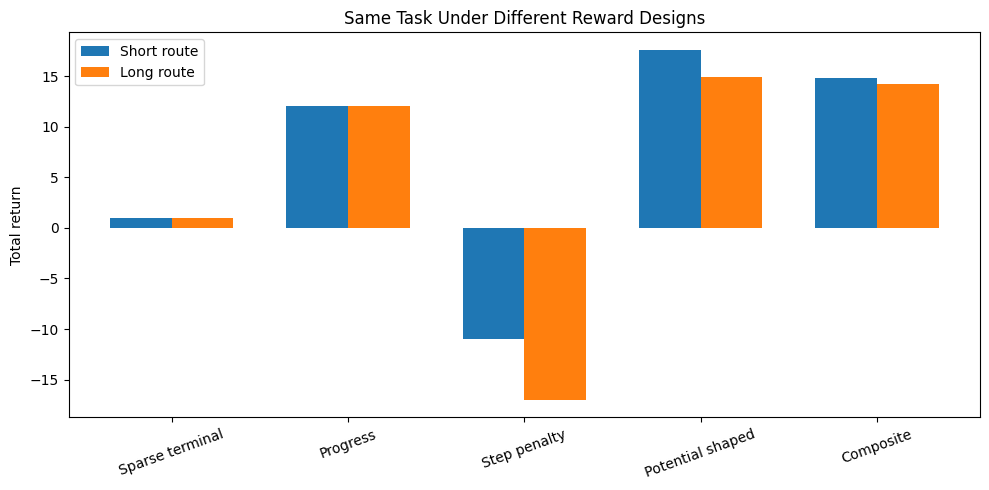

In [18]:
x = np.arange(len(reward_check))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(
    x - width / 2,
    reward_check["Short-route return"],
    width,
    label="Short route",
)
plt.bar(
    x + width / 2,
    reward_check["Long-route return"],
    width,
    label="Long route",
)

plt.xticks(x, reward_check["Reward type"], rotation=20)
plt.ylabel("Total return")
plt.title("Same Task Under Different Reward Designs")
plt.legend()
plt.tight_layout()
plt.show()

The result illustrates why reward testing is important:

- sparse reward may treat both successful routes equally,
- progress reward can cancel unnecessary back-and-forth movement,
- step penalties explicitly prefer fewer steps,
- shaped and composite rewards can provide guidance while still preferring efficient behavior.

# 21. Practical Selection Guide

### Choose a sparse reward when

- success is easy to discover,
- the task is short,
- you want minimal assumptions.

### Choose a dense reward when

- progress can be measured,
- sparse exploration is difficult.

### Choose a step penalty when

- time, path length, or resource usage matters.

### Choose shaping when

- the base reward is too sparse,
- domain knowledge provides useful intermediate guidance.

### Choose a composite reward when

- multiple objectives genuinely matter.

### Choose total reward when

- the task is finite and episodic.

### Choose discounted return when

- future rewards matter but earlier rewards should count more.

### Choose average reward when

- the task is continuing and steady-state performance per time step is the real objective.

# 22. Final Summary

Reward design has two separate layers.

## Immediate reward

$$
R_{t+1}
=
R(S_t,A_t,S_{t+1})
$$

Possible forms include:

- sparse,
- dense,
- step-cost,
- shaped,
- composite,
- intrinsic + extrinsic.

## Reward criterion

### Total

$$
G
=
\sum_{t=1}^{T}R_t
$$

### Discounted

$$
G_t
=
\sum_{k=0}^{\infty}
\gamma^kR_{t+k+1}
$$

### Average

$$
\rho
=
\lim_{n\to\infty}
\frac1n
\mathbb E
\left[
\sum_{t=1}^{n}R_t
\right]
$$

A useful reward should be:

- aligned with the true objective,
- informative enough to learn,
- correctly scaled,
- consistent with the desired time preference,
- difficult to exploit,
- compatible with safety requirements,
- validated by examining actual behavior.